In [6]:
%pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --

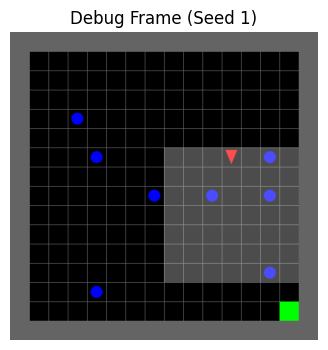

Update: 17459 | Frames: 30068992
U 17459 | F 30068992 | FPS 0934 | D 84 | rR:μσmM 8.14 4.70 -5.36 9.98 | F:μσmM 49.3 15.4 2.0 108.0 | H 0.427 | V 6.702 | pL -0.115 | vL 2.584 | ∇ 4.672


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\vikas\miniconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vikas\miniconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode characters in position 44-45: character maps to <undefined>
Call stack:
  File "C:\Users\vikas\miniconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\vikas\miniconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\vikas\OneDrive\Desktop\CSE_PROJ\minigrid_static_fullobs\minigrid-static-fullobs\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\vikas\O

KeyboardInterrupt: 

In [1]:

import argparse
import time
import datetime
import torch_ac
import tensorboardX
import sys
import os
sys.path.append('/mnt/c/Users/vikas/OneDrive/Desktop/CSE_PROJ/minigrid_static_fullobs/minigrid-static-fullobs')
import utils
from utils import device
from model import ACModel
import matplotlib.pyplot as plt

def debug_plot_frame(frame_input):
    """
    Plots a single frame inline.
    Input: Numpy array (Height, Width, 3)
    """
    plt.figure(figsize=(4,4))
    
    # Check if input is a PyTorch tensor, convert to numpy if so
    if hasattr(frame_input, 'cpu'):
        frame_input = frame_input.cpu().numpy()
        # If channel-first (3, H, W), swap to (H, W, 3) for matplotlib
        if frame_input.shape[0] == 3: 
            frame_input = np.transpose(frame_input, (1, 2, 0))
            
    plt.imshow(frame_input)
    plt.axis('off')
    plt.title("Debug Frame (Seed 1)")
    plt.show()

sys.argv = [
    'train.py',
    '--algo', 'ppo',                   # Algorithm
    '--env', 'MiniGrid-Dynamic-Obstacles-16x16-v0',  # Environment ID
    '--model', 'random_ranreward_16',         # Name to save the model as
    '--seed', '1',                     # STRICTLY ENFORCE SEED 1
    '--save-interval', '10',           # Save model every 10 updates
    '--frames', '32000000',               # Total training frames
    '--log-interval', '1'              # Log status every 1 update
]
# Parse arguments

parser = argparse.ArgumentParser()

# General parameters
parser.add_argument("--algo", required=True,
                    help="algorithm to use: a2c | ppo (REQUIRED)")
parser.add_argument("--env", required=True,
                    help="name of the environment to train on (REQUIRED)")
parser.add_argument("--model", default=None,
                    help="name of the model (default: {ENV}_{ALGO}_{TIME})")
parser.add_argument("--seed", type=int, default=1,
                    help="random seed (default: 1)")
parser.add_argument("--log-interval", type=int, default=1,
                    help="number of updates between two logs (default: 1)")
parser.add_argument("--save-interval", type=int, default=10,
                    help="number of updates between two saves (default: 10, 0 means no saving)")
parser.add_argument("--procs", type=int, default=16,
                    help="number of processes (default: 16)")
parser.add_argument("--frames", type=int, default=10**7,
                    help="number of frames of training (default: 1e7)")

# Parameters for main algorithm
parser.add_argument("--epochs", type=int, default=4,
                    help="number of epochs for PPO (default: 4)")
parser.add_argument("--batch-size", type=int, default=256,
                    help="batch size for PPO (default: 256)")
parser.add_argument("--frames-per-proc", type=int, default=None,
                    help="number of frames per process before update (default: 5 for A2C and 128 for PPO)")
parser.add_argument("--discount", type=float, default=0.99,
                    help="discount factor (default: 0.99)")
parser.add_argument("--lr", type=float, default=0.001,
                    help="learning rate (default: 0.001)")
parser.add_argument("--gae-lambda", type=float, default=0.95,
                    help="lambda coefficient in GAE formula (default: 0.95, 1 means no gae)")
parser.add_argument("--entropy-coef", type=float, default=0.01,
                    help="entropy term coefficient (default: 0.01)")
parser.add_argument("--value-loss-coef", type=float, default=0.5,
                    help="value loss term coefficient (default: 0.5)")
parser.add_argument("--max-grad-norm", type=float, default=0.5,
                    help="maximum norm of gradient (default: 0.5)")
parser.add_argument("--optim-eps", type=float, default=1e-8,
                    help="Adam and RMSprop optimizer epsilon (default: 1e-8)")
parser.add_argument("--optim-alpha", type=float, default=0.99,
                    help="RMSprop optimizer alpha (default: 0.99)")
parser.add_argument("--clip-eps", type=float, default=0.2,
                    help="clipping epsilon for PPO (default: 0.2)")
parser.add_argument("--recurrence", type=int, default=1,
                    help="number of time-steps gradient is backpropagated (default: 1). If > 1, a LSTM is added to the model to have memory.")
parser.add_argument("--text", action="store_true", default=False,
                    help="add a GRU to the model to handle text input")

if __name__ == "__main__":
    args = parser.parse_args()

    args.mem = args.recurrence > 1

    # Set run dir

    date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M-%S")
    default_model_name = f"{args.env}_{args.algo}_seed{args.seed}_{date}"

    model_name = args.model or default_model_name
    model_dir = utils.get_model_dir(model_name)

    # Load loggers and Tensorboard writer

    txt_logger = utils.get_txt_logger(model_dir)
    csv_file, csv_logger = utils.get_csv_logger(model_dir)
    tb_writer = tensorboardX.SummaryWriter(model_dir)

    # Log command and all script arguments

    txt_logger.info("{}\n".format(" ".join(sys.argv)))
    txt_logger.info("{}\n".format(args))

    # Set seed for all randomness sources

    utils.seed(args.seed)

    # Set device

    txt_logger.info(f"Device: {device}\n")

    # Load environments

    envs = []
    itr=0
    for i in range(args.procs):
        envs.append(utils.make_env(args.env, args.seed,render_mode='rgb_array'))
        if hasattr(envs, 'envs'):
            # If it is a Vectorized Env
            img = envs.envs[i].render()
        else:
            # If it is a list
            img = envs[i].render()

        if itr<5:
          debug_plot_frame(img)
          itr+=1

    txt_logger.info("Environments loaded\n")

    # Load training status

    try:
        status = utils.get_status(model_dir)
    except OSError:
        status = {"num_frames": 0, "update": 0}
    txt_logger.info("Training status loaded\n")

    # Load observations preprocessor

    obs_space, preprocess_obss = utils.get_obss_preprocessor(envs[0].observation_space)
    if "vocab" in status:
        preprocess_obss.vocab.load_vocab(status["vocab"])
    txt_logger.info("Observations preprocessor loaded")

    # Load model

    acmodel = ACModel(obs_space, envs[0].action_space, args.mem, args.text)
    if "model_state" in status:
        acmodel.load_state_dict(status["model_state"])
    acmodel.to(device)
    txt_logger.info("Model loaded\n")
    txt_logger.info("{}\n".format(acmodel))

    # Load algo

    if args.algo == "a2c":
        algo = torch_ac.A2CAlgo(envs, acmodel, device, args.frames_per_proc, args.discount, args.lr, args.gae_lambda,
                                args.entropy_coef, args.value_loss_coef, args.max_grad_norm, args.recurrence,
                                args.optim_alpha, args.optim_eps, preprocess_obss)
    elif args.algo == "ppo":
        algo = torch_ac.PPOAlgo(envs, acmodel, device, args.frames_per_proc, args.discount, args.lr, args.gae_lambda,
                                args.entropy_coef, args.value_loss_coef, args.max_grad_norm, args.recurrence,
                                args.optim_eps, args.clip_eps, args.epochs, args.batch_size, preprocess_obss)
    else:
        raise ValueError("Incorrect algorithm name: {}".format(args.algo))

    if "optimizer_state" in status:
        algo.optimizer.load_state_dict(status["optimizer_state"])
    txt_logger.info("Optimizer loaded\n")


    # Train model

    num_frames = status["num_frames"]
    update = status["update"]
    start_time = time.time()

    while num_frames < args.frames:
        # Update model parameters
        update_start_time = time.time()
        exps, logs1 = algo.collect_experiences()
        logs2 = algo.update_parameters(exps)
        logs = {**logs1, **logs2}
        update_end_time = time.time()

        num_frames += logs["num_frames"]
        update += 1

        # Print logs

        if update % args.log_interval == 0:
            fps = logs["num_frames"] / (update_end_time - update_start_time)
            duration = int(time.time() - start_time)
            return_per_episode = utils.synthesize(logs["return_per_episode"])
            rreturn_per_episode = utils.synthesize(logs["reshaped_return_per_episode"])
            num_frames_per_episode = utils.synthesize(logs["num_frames_per_episode"])
##### check if the training seed is correct
            try:
                # 1. Clear previous plot to avoid stacking thousands of images
                from IPython.display import clear_output
                clear_output(wait=True) 

                # 2. Get the frame from the FIRST environment instance
                # Note: envs is a list of environment objects you created earlier
                if hasattr(envs[0], 'render'):
                    frame = envs[0].render() # Call render directly
                    debug_plot_frame(frame)
                    print(f"Update: {update} | Frames: {num_frames}")
            except Exception as e:
                print(f"Could not print frame: {e}")
############### end check----
            header = ["update", "frames", "FPS", "duration"]
            data = [update, num_frames, fps, duration]
            header += ["rreturn_" + key for key in rreturn_per_episode.keys()]
            data += rreturn_per_episode.values()
            header += ["num_frames_" + key for key in num_frames_per_episode.keys()]
            data += num_frames_per_episode.values()
            header += ["entropy", "value", "policy_loss", "value_loss", "grad_norm"]
            data += [logs["entropy"], logs["value"], logs["policy_loss"], logs["value_loss"], logs["grad_norm"]]

            txt_logger.info(
                "U {} | F {:06} | FPS {:04.0f} | D {} | rR:μσmM {:.2f} {:.2f} {:.2f} {:.2f} | F:μσmM {:.1f} {:.1f} {} {} | H {:.3f} | V {:.3f} | pL {:.3f} | vL {:.3f} | ∇ {:.3f}"
                .format(*data))

            header += ["return_" + key for key in return_per_episode.keys()]
            data += return_per_episode.values()

            if status["num_frames"] == 0:
                csv_logger.writerow(header)
            csv_logger.writerow(data)
            csv_file.flush()

            for field, value in zip(header, data):
                tb_writer.add_scalar(field, value, num_frames)

        # Save status

        if args.save_interval > 0 and update % args.save_interval == 0:
            status = {"num_frames": num_frames, "update": update,
                      "model_state": acmodel.state_dict(), "optimizer_state": algo.optimizer.state_dict()}
            if hasattr(preprocess_obss, "vocab"):
                status["vocab"] = preprocess_obss.vocab.vocab
            utils.save_status(status, model_dir)
            txt_logger.info("Status saved")
